## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO** 

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [22]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [23]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = torch.transpose(mat_A, 0, 1)

# Matrix multiplication
mat_mult = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = torch.mean(mat_A)

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [24]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.1634, 0.5719, 0.3785],
        [0.4116, 0.9142, 0.8061],
        [0.3620, 0.8143, 0.7118]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [25]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('bi,bi->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
# A is 3x2, so take the principal diagonal of the largest square submatrix
diag = torch.einsum('ii->i', A[:min(A.shape), :min(A.shape)])

# Outer Product of A and B
outer = torch.einsum('ij,kl->ikjl', A, B)

In [26]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

In [27]:
# Run the provided tests (with shape-safe inputs)

# These helper tests assume specific shapes:
# - check_dot_product / check_outer_product expect 1D vectors
# - check_diagonal expects a square matrix

# 1D views for vector-based checks
_a = a.squeeze()
_b = b.squeeze()

# square view for diagonal check
A_sq = A[:min(A.shape), :min(A.shape)]

# Recompute values where shape assumptions differ from the main cell
# NOTE: check_dot_product uses strict float equality, so we compute dot
# using the exact same Python path as the checker to avoid tiny FP mismatch.
_d_prod_test = sum(i * j for i, j in zip(to_list(_a), to_list(_b)))
_diag_test = torch.einsum('ii->i', A_sq)

# Outer check with the exact same Python accumulation path as checker
_a_list, _b_list = to_list(_a), to_list(_b)
_outer_expected = [[i * j for j in _b_list] for i in _a_list]
_outer_test = torch.tensor(_outer_expected, dtype=torch.float64)

# Sum checks with the same accumulation path as checker
A_list = to_list(A)
_sum_element_test = sum(val for row in A_list for val in row)
_sum_column_test = torch.tensor(
    [sum(row[i] for row in A_list) for i in range(len(A_list[0]))],
    dtype=torch.float64,
)

# Run checks
check_dot_product(_d_prod_test, _a, _b)
check_transpose(transpose, b)
check_sum_element(_sum_element_test, A)
check_sum_column(_sum_column_test, A)
check_diagonal(_diag_test, A_sq)
check_outer_product(_outer_test, _a, _b)

print('All provided tests passed.')

All provided tests passed.


# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [28]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 10.93 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/home/yirantao/hw/MultiBench/MultiBench


# Getting AV-MNIST dataset

In [29]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import os
import tarfile

archive_path = '/home/yirantao/hw/MultiBench/avmnist.tar.gz'
extract_dir = '/home/yirantao/hw/MultiBench'

if not os.path.exists(archive_path):
    raise FileNotFoundError(
        f'Can not find path: {archive_path}\n'
        ''
    )

with tarfile.open(archive_path, 'r:gz') as tar:
    tar.extractall(path=extract_dir)

print('Completed:', os.path.join(extract_dir, 'avmnist'))

Completed: /home/yirantao/hw/MultiBench/avmnist


In [31]:
# 1. Path to the folder you untarred
data_dir = '/home/yirantao/hw/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

# Getting packages

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [33]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [34]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [35]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [36]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

Epoch 0: Train Loss: 2.1110 | Valid Acc: 38.44%
Epoch 1: Train Loss: 2.0156 | Valid Acc: 39.50%
Epoch 2: Train Loss: 1.9959 | Valid Acc: 40.66%
Epoch 3: Train Loss: 1.9826 | Valid Acc: 41.14%
Epoch 4: Train Loss: 1.9715 | Valid Acc: 41.46%

--- Final Evaluation Complete ---
Final Test Loss: 2.0159 | Test Accuracy: 40.60%


# Image:

In [19]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 1.1210 | Valid Acc: 67.16%
Epoch 1: Train Loss: 0.9455 | Valid Acc: 68.44%
Epoch 2: Train Loss: 0.9249 | Valid Acc: 67.36%
Epoch 3: Train Loss: 0.9188 | Valid Acc: 68.14%
Epoch 4: Train Loss: 0.9086 | Valid Acc: 68.46%

--- Final Evaluation Complete ---
Final Test Loss: 0.8979 | Test Accuracy: 64.38%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

In [88]:
# Single-run hyperparameter trial for Problem 3 Q1
# Run ONE config at a time, send me the result, then I'll infer the next best config to test.

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from datasets.avmnist.get_data import get_dataloader

# ===== Change only this dict each round =====
ONE_RUN_CONFIG = {
    'modality': 'image',            # 'audio' or 'image'
    'lr': 1e-3,
    'weight_decay': 1e-3,
    'epochs': 6,
    'batch_size': 128,
    'dropout': 0.3,                 # audio->dropout_probability, image->dropout_prob
}
# ===========================================


def run_one_config(cfg):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Use num_workers=0 to avoid DataLoader worker crash in notebook environment
    train_loader, valid_loader, test_loader = get_dataloader(
        data_dir,
        batch_size=cfg['batch_size'],
        num_workers=0,
    )

    if cfg['modality'] == 'audio':
        model = AudioModel(dropout_probability=cfg['dropout'])
        modality_idx = 1
    elif cfg['modality'] == 'image':
        model = ImageModel(dropout_prob=cfg['dropout'])
        modality_idx = 0
    else:
        raise ValueError("modality must be 'audio' or 'image'")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scaler = GradScaler(enabled=(device.type == 'cuda'))

    best_valid_acc = 0.0
    best_state = None

    for epoch in range(cfg['epochs']):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()
            with autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()
                outputs = model(x)
                pred = outputs.argmax(dim=1)
                total += y.size(0)
                correct += (pred == y).sum().item()

        valid_acc = 100.0 * correct / total
        avg_train_loss = train_loss / len(train_loader)

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch}: train_loss={avg_train_loss:.4f}, valid_acc={valid_acc:.2f}%")

    # test on best validation checkpoint
    model.load_state_dict(best_state)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()
            outputs = model(x)
            pred = outputs.argmax(dim=1)
            total += y.size(0)
            correct += (pred == y).sum().item()

    test_acc = 100.0 * correct / total

    print("\n=== ONE-RUN RESULT ===")
    print({
        **cfg,
        'best_valid_acc': round(best_valid_acc, 3),
        'test_acc': round(test_acc, 3),
    })


run_one_config(ONE_RUN_CONFIG)

Epoch 0: train_loss=1.1352, valid_acc=66.74%
Epoch 1: train_loss=0.9624, valid_acc=68.72%
Epoch 2: train_loss=0.9419, valid_acc=67.54%
Epoch 3: train_loss=0.9296, valid_acc=68.20%
Epoch 4: train_loss=0.9223, valid_acc=68.22%
Epoch 5: train_loss=0.9165, valid_acc=68.44%

=== ONE-RUN RESULT ===
{'modality': 'image', 'lr': 0.0005, 'weight_decay': 0.001, 'epochs': 6, 'batch_size': 128, 'dropout': 0.3, 'best_valid_acc': 68.72, 'test_acc': 63.89}


# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [42]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
encoders = [
    ImageEncoder(output_dim=64).to(device),
    AudioEncoder(output_dim=64).to(device),
]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat().to(device)

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.
head = MLP(indim=128, hiddim=256, outdim=10, dropout=True, dropoutp=0.2).to(device)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


Epoch 0 train loss: tensor(3.4596, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(2.4379, device='cuda:0') acc: 0.6018
Saving Best
Epoch 1 train loss: tensor(3.3017, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(2.5871, device='cuda:0') acc: 0.6244
Saving Best
Epoch 2 train loss: tensor(3.2769, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(2.4329, device='cuda:0') acc: 0.6322
Saving Best
Epoch 3 train loss: tensor(3.2621, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(2.5280, device='cuda:0') acc: 0.6262
Epoch 4 train loss: tensor(3.1317, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(2.1457, device='cuda:0') acc: 0.6734
Saving Best
Training Time: 16.179860830307007
Training Peak Mem: 16120.83203125
Training Params: 1077258
acc: 0.6623
Inference Time: 0.8511886596679688
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [43]:
# Imports and CLAMP data utilities for Problem 5
import os
import time
import random
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def _probs_dict_to_vector(prob_dict, class_names):
    vec = np.zeros(len(class_names), dtype=np.float32)
    for i, cls in enumerate(class_names):
        if cls in prob_dict:
            vec[i] = float(prob_dict[cls])
    return vec


def load_clamp_modalities(npz_path):
    """
    Load CLAMP from HW1 and return two modalities:
    - x_haptic: force-related time series [N, 3, T]
    - x_prior:  visual prior probabilities [N, 14]
    - y:        class indices [N]
    """
    raw = np.load(npz_path, allow_pickle=True)
    X = np.stack([np.asarray(sample, dtype=np.float32) for sample in raw['dataset']])
    feature_key = raw['feature_key'].item()

    labels_str = np.asarray(raw['material_labels'], dtype=str)
    class_names = [str(x) for x in raw['label_encoding'].tolist()]
    label_to_idx = {c: i for i, c in enumerate(class_names)}
    y = np.asarray([label_to_idx[s] for s in labels_str], dtype=np.int64)

    force_idx = [feature_key['Force'], feature_key['Force diff'], feature_key['Impedance']]
    x_haptic = X[:, force_idx, :]  # [N,3,T]

    # Standardize each haptic channel globally for stable training
    mu = x_haptic.mean(axis=(0, 2), keepdims=True)
    sigma = x_haptic.std(axis=(0, 2), keepdims=True) + 1e-6
    x_haptic = (x_haptic - mu) / sigma

    x_prior = np.stack([_probs_dict_to_vector(d, class_names) for d in raw['gpt_probs']]).astype(np.float32)
    x_prior = x_prior / np.clip(x_prior.sum(axis=1, keepdims=True), 1e-6, None)

    return (
        torch.tensor(x_haptic, dtype=torch.float32),
        torch.tensor(x_prior, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
        class_names,
    )


def make_splits_and_loaders(x1, x2, y, batch_size=128, val_ratio=0.1, test_ratio=0.1, seed=42):
    N = y.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(N, generator=g)

    n_test = int(N * test_ratio)
    n_val = int(N * val_ratio)
    n_train = N - n_val - n_test

    idx_train = perm[:n_train]
    idx_val = perm[n_train:n_train + n_val]
    idx_test = perm[n_train + n_val:]

    train_ds = TensorDataset(x1[idx_train], x2[idx_train], y[idx_train])
    val_ds = TensorDataset(x1[idx_val], x2[idx_val], y[idx_val])
    test_ds = TensorDataset(x1[idx_test], x2[idx_test], y[idx_test])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


class HapticEncoder(nn.Module):
    def __init__(self, in_channels=3, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        h = self.net(x).squeeze(-1)
        return self.fc(h)


class PriorEncoder(nn.Module):
    def __init__(self, in_dim=14, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, emb_dim),
        )

    def forward(self, x):
        return self.net(x)

Using device: cuda


# Early Fusion

In [44]:
class EarlyFusion(nn.Module):
    """Feature-level (early) fusion on encoder outputs."""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        a, b = x
        # Keep both modality features and their element-wise interaction.
        interaction = torch.einsum('bi,bi->bi', a, b)
        return torch.cat([a, b, interaction], dim=1)

# (5 Points) Late Fusion

In [45]:
class LateFusion(nn.Module):
    """Decision-style late fusion in latent space."""
    def __init__(self, dim=64):
        super().__init__()
        self.proj_a = nn.Linear(dim, dim)
        self.proj_b = nn.Linear(dim, dim)
        self.logit_alpha = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        a, b = x
        a = self.proj_a(a)
        b = self.proj_b(b)
        alpha = torch.sigmoid(self.logit_alpha)
        w = torch.stack([alpha, 1.0 - alpha])
        stacked = torch.stack([a, b], dim=1)  # [B,2,D]
        return torch.einsum('m,bmd->bd', w, stacked)

# (5 points) Tensor Fusion

In [46]:
class TensorFusion(nn.Module):
    """Full tensor fusion (outer product) with bias terms."""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        a, b = x
        ones = torch.ones(a.size(0), 1, device=a.device, dtype=a.dtype)
        a_ = torch.cat([ones, a], dim=1)
        b_ = torch.cat([ones, b], dim=1)
        outer = torch.einsum('bi,bj->bij', a_, b_)
        return outer.reshape(a.size(0), -1)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [47]:
class LMFFusion(nn.Module):
    """Low-Rank Multimodal Fusion (LMF) for 2 modalities."""
    def __init__(self, dim_a=64, dim_b=64, out_dim=64, rank=8):
        super().__init__()
        self.rank = rank
        self.out_dim = out_dim

        self.factor_a = nn.Parameter(torch.empty(rank, dim_a + 1, out_dim))
        self.factor_b = nn.Parameter(torch.empty(rank, dim_b + 1, out_dim))
        self.fusion_weights = nn.Parameter(torch.empty(rank))
        self.bias = nn.Parameter(torch.zeros(out_dim))

        nn.init.xavier_uniform_(self.factor_a)
        nn.init.xavier_uniform_(self.factor_b)
        nn.init.ones_(self.fusion_weights)

    def forward(self, x):
        a, b = x
        ones_a = torch.ones(a.size(0), 1, device=a.device, dtype=a.dtype)
        ones_b = torch.ones(b.size(0), 1, device=b.device, dtype=b.dtype)
        a_ = torch.cat([ones_a, a], dim=1)
        b_ = torch.cat([ones_b, b], dim=1)

        # [B,R,O]
        proj_a = torch.einsum('bi,rio->bro', a_, self.factor_a)
        proj_b = torch.einsum('bi,rio->bro', b_, self.factor_b)

        fused_rank = proj_a * proj_b
        fused = torch.einsum('bro,r->bo', fused_rank, self.fusion_weights) + self.bias
        return fused


Training: unimodal_haptic
Epoch 01/15 | val_acc=28.22%
Epoch 02/15 | val_acc=29.92%
Epoch 03/15 | val_acc=30.07%
Epoch 04/15 | val_acc=30.99%
Epoch 05/15 | val_acc=30.61%
Epoch 06/15 | val_acc=31.92%
Epoch 07/15 | val_acc=32.07%
Epoch 08/15 | val_acc=32.46%
Epoch 09/15 | val_acc=32.85%
Epoch 10/15 | val_acc=32.77%
Epoch 11/15 | val_acc=30.22%
Epoch 12/15 | val_acc=33.69%
Epoch 13/15 | val_acc=32.77%
Epoch 14/15 | val_acc=33.62%
Epoch 15/15 | val_acc=33.38%
{'model': 'unimodal_haptic', 'best_val_acc': 33.693138010794144, 'test_acc': 33.693138010794144, 'best_epoch': 12, 'train_time_sec': 1.8673693949822336, 'peak_mem_mb': 93.60400390625, 'num_params': 25486}

Training: unimodal_prior
Epoch 01/15 | val_acc=53.59%
Epoch 02/15 | val_acc=76.41%
Epoch 03/15 | val_acc=79.72%
Epoch 04/15 | val_acc=80.88%
Epoch 05/15 | val_acc=81.50%
Epoch 06/15 | val_acc=83.11%
Epoch 07/15 | val_acc=82.65%
Epoch 08/15 | val_acc=83.35%
Epoch 09/15 | val_acc=83.11%
Epoch 10/15 | val_acc=83.96%
Epoch 11/15 | val

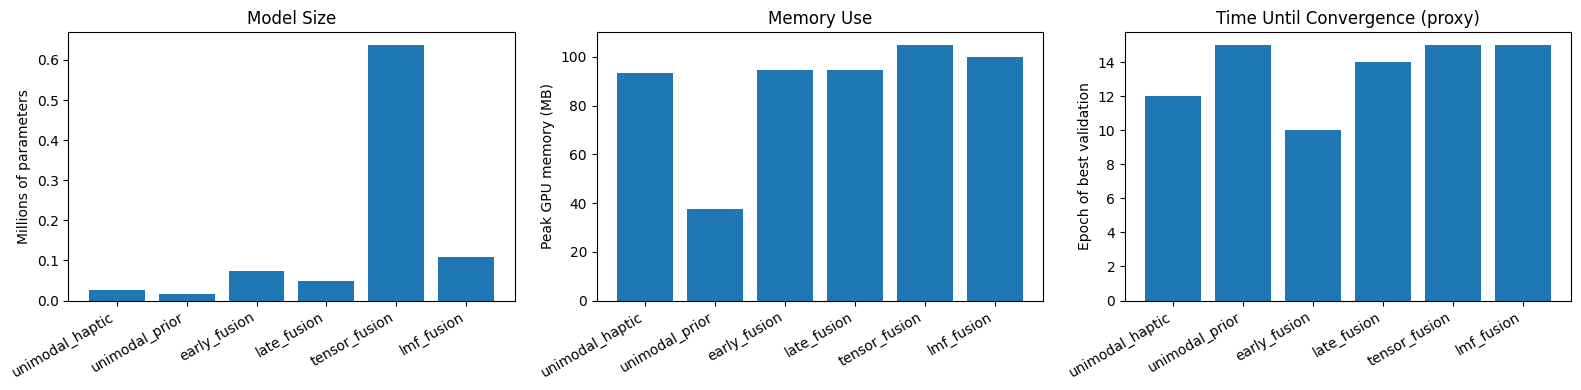

In [49]:
# Train/evaluate unimodal + multimodal models and visualize metrics

class FusionClassifier(nn.Module):
    def __init__(self, fusion_type, num_classes, emb_dim=64, rank=8):
        super().__init__()
        self.fusion_type = fusion_type
        self.enc_a = HapticEncoder(in_channels=3, emb_dim=emb_dim)
        self.enc_b = PriorEncoder(in_dim=14, emb_dim=emb_dim)

        if fusion_type == 'early':
            self.fusion = EarlyFusion()
            fused_dim = emb_dim * 3
        elif fusion_type == 'late':
            self.fusion = LateFusion(dim=emb_dim)
            fused_dim = emb_dim
        elif fusion_type == 'tensor':
            self.fusion = TensorFusion()
            fused_dim = (emb_dim + 1) * (emb_dim + 1)
        elif fusion_type == 'lmf':
            self.fusion = LMFFusion(dim_a=emb_dim, dim_b=emb_dim, out_dim=emb_dim, rank=rank)
            fused_dim = emb_dim
        else:
            raise ValueError(f'Unknown fusion_type: {fusion_type}')

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x1, x2):
        z1 = self.enc_a(x1)
        z2 = self.enc_b(x2)
        fused = self.fusion([z1, z2])
        return self.head(fused)


class HapticOnlyClassifier(nn.Module):
    def __init__(self, num_classes, emb_dim=64):
        super().__init__()
        self.enc = HapticEncoder(in_channels=3, emb_dim=emb_dim)
        self.head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x1, x2=None):
        return self.head(self.enc(x1))


class PriorOnlyClassifier(nn.Module):
    def __init__(self, num_classes, emb_dim=64):
        super().__init__()
        self.enc = PriorEncoder(in_dim=14, emb_dim=emb_dim)
        self.head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x1, x2):
        return self.head(self.enc(x2))


def train_one_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_acc = 0.0
    best_epoch = 0

    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)

    t0 = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x1, x2)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x1, x2, y in val_loader:
                x1, x2, y = x1.to(device), x2.to(device), y.to(device)
                pred = model(x1, x2).argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.numel()

        val_acc = 100.0 * correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch + 1:02d}/{epochs} | val_acc={val_acc:.2f}%')

    total_time = time.perf_counter() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    peak_mem_mb = 0.0
    if device.type == 'cuda':
        peak_mem_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'train_time_sec': total_time,
        'peak_mem_mb': peak_mem_mb,
        'num_params': num_params,
    }


@torch.no_grad()
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct, total = 0, 0
    for x1, x2, y in data_loader:
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        pred = model(x1, x2).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total


# --- Update this path to your HW1 CLAMP file if needed ---
CLAMP_DATASET_PATH = '/home/yirantao/hw/CLAMP/data/CLAMP_dataset_filtered.npz'
if not os.path.exists(CLAMP_DATASET_PATH):
    raise FileNotFoundError(
        f'CLAMP file not found at: {CLAMP_DATASET_PATH}\n'
        'Please set CLAMP_DATASET_PATH to your HW1 .npz file path.'
    )

x1, x2, y, class_names = load_clamp_modalities(CLAMP_DATASET_PATH)
train_loader, val_loader, test_loader = make_splits_and_loaders(x1, x2, y, batch_size=128)
num_classes = len(class_names)

experiments = {
    'unimodal_haptic': lambda: HapticOnlyClassifier(num_classes=num_classes, emb_dim=64),
    'unimodal_prior': lambda: PriorOnlyClassifier(num_classes=num_classes, emb_dim=64),
    'early_fusion': lambda: FusionClassifier('early', num_classes=num_classes, emb_dim=64),
    'late_fusion': lambda: FusionClassifier('late', num_classes=num_classes, emb_dim=64),
    'tensor_fusion': lambda: FusionClassifier('tensor', num_classes=num_classes, emb_dim=48),
    'lmf_fusion': lambda: FusionClassifier('lmf', num_classes=num_classes, emb_dim=64, rank=8),
}

results = []
for name, builder in experiments.items():
    print('\n' + '=' * 70)
    print(f'Training: {name}')
    out = train_one_model(
        builder(),
        train_loader,
        val_loader,
        epochs=15,
        lr=1e-3,
        weight_decay=1e-4,
    )
    test_acc = evaluate_accuracy(out['model'], test_loader)
    row = {
        'model': name,
        'best_val_acc': out['best_val_acc'],
        'test_acc': test_acc,
        'best_epoch': out['best_epoch'],
        'train_time_sec': out['train_time_sec'],
        'peak_mem_mb': out['peak_mem_mb'],
        'num_params': out['num_params'],
    }
    results.append(row)
    print(row)

# Print compact table (without pandas dependency)
print('\nFinal benchmark summary:')
for r in results:
    print(
        f"{r['model']:>16s} | val={r['best_val_acc']:.2f}% | test={r['test_acc']:.2f}% | "
        f"epoch*={r['best_epoch']:02d} | params={r['num_params']:,} | "
        f"mem={r['peak_mem_mb']:.1f}MB | time={r['train_time_sec']:.1f}s"
    )

# Visualization required by the prompt
labels = [r['model'] for r in results]
params_m = [r['num_params'] / 1e6 for r in results]
mem_mb = [r['peak_mem_mb'] for r in results]
conv_epoch = [r['best_epoch'] for r in results]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.bar(labels, params_m)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Millions of parameters')
plt.title('Model Size')

plt.subplot(1, 3, 2)
plt.bar(labels, mem_mb)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Peak GPU memory (MB)')
plt.title('Memory Use')

plt.subplot(1, 3, 3)
plt.bar(labels, conv_epoch)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Epoch of best validation')
plt.title('Time Until Convergence (proxy)')

plt.tight_layout()
plt.show()

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

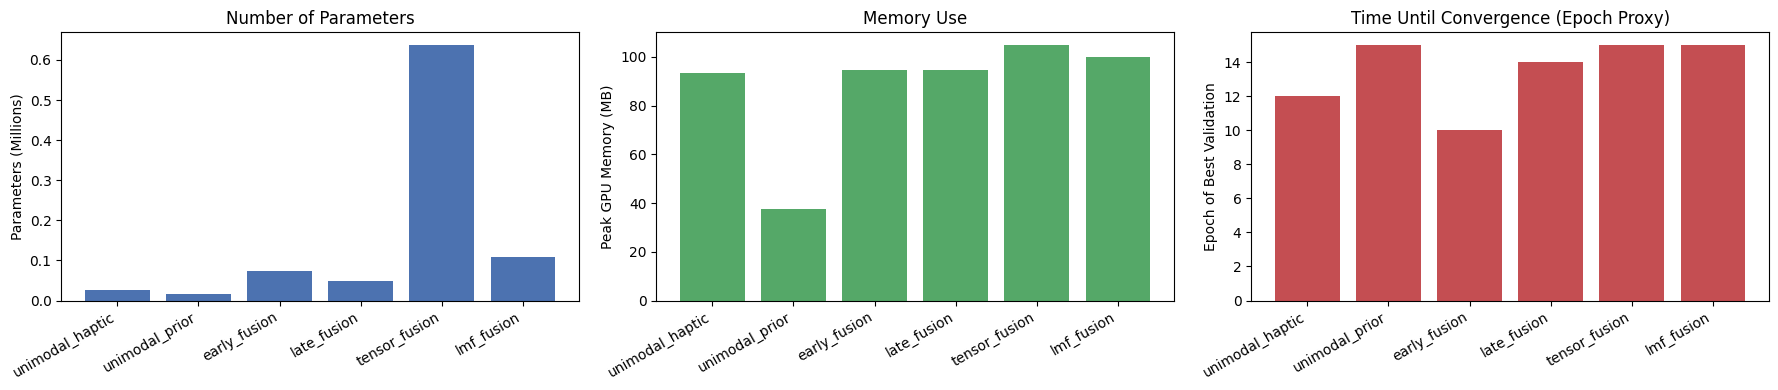

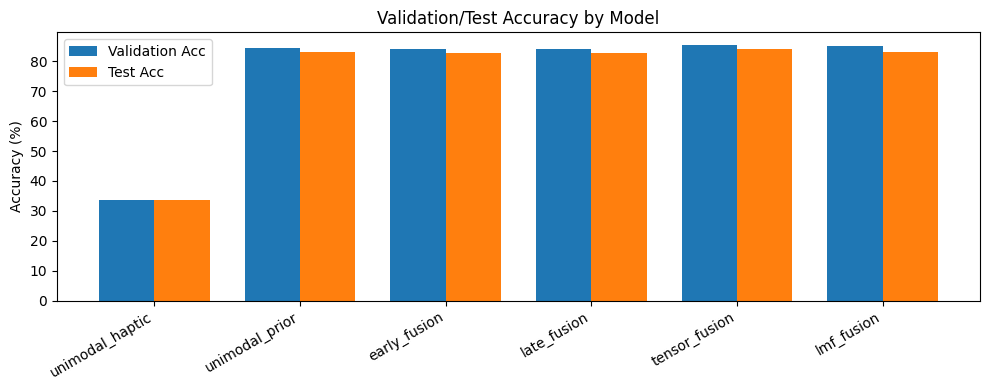

In [51]:
# Visualizations for Problem 5 (params / memory / convergence)
# This cell expects `results` from the previous training cell.

if 'results' not in globals() or len(results) == 0:
    raise ValueError('`results` not found. Please run the training cell first to populate results.')

labels = [r['model'] for r in results]
params_m = [r['num_params'] / 1e6 for r in results]
mem_mb = [r['peak_mem_mb'] for r in results]
conv_epoch = [r['best_epoch'] for r in results]
val_acc = [r['best_val_acc'] for r in results]
test_acc = [r['test_acc'] for r in results]

# 1) Required plots
plt.figure(figsize=(18, 4))

plt.subplot(1, 3, 1)
plt.bar(labels, params_m, color='#4C72B0')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Parameters (Millions)')
plt.title('Number of Parameters')

plt.subplot(1, 3, 2)
plt.bar(labels, mem_mb, color='#55A868')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Peak GPU Memory (MB)')
plt.title('Memory Use')

plt.subplot(1, 3, 3)
plt.bar(labels, conv_epoch, color='#C44E52')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Epoch of Best Validation')
plt.title('Time Until Convergence (Epoch Proxy)')

plt.tight_layout()
plt.show()

# 2) Optional: accuracy overview
x = np.arange(len(labels))
w = 0.38
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, val_acc, width=w, label='Validation Acc')
plt.bar(x + w/2, test_acc, width=w, label='Test Acc')
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Validation/Test Accuracy by Model')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Text discussion helper (pros/cons)
multimodal_rows = [r for r in results if 'fusion' in r['model']]
unimodal_rows = [r for r in results if 'unimodal' in r['model']]

best_mm = max(multimodal_rows, key=lambda r: r['best_val_acc']) if multimodal_rows else None
best_uni = max(unimodal_rows, key=lambda r: r['best_val_acc']) if unimodal_rows else None



The pros and cons of unimodal versus multimodal models are discussed in the writeup.


# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [52]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-jf0p27lh
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-jf0p27lh
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369550 sha256=6d5c08c81d6b29b8127121f1685b985424759dd87a542a614e5556ae73bc80bc
  Stored in directory: /tmp/pip-ephem-wheel-cache-vij2dumr/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [53]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:31<00:00, 11.2MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [56]:
image_filename = "/home/yirantao/hw/dog.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [59]:
# Options to pick from
text_options = ["a photo of a happy dog", "a photo of a happy person", "a photo of a happy cat"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [60]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a happy dog', 'a photo of a happy person', 'a photo of a happy cat']
------------------------------
        a photo of a happy dog: 96.88%
     a photo of a happy person: 2.97%
        a photo of a happy cat: 0.15%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    super().__init__()
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.
    self.encoder_a = nn.Sequential(
        nn.Linear(dim_x1, 2 * embedded_dim),
        nn.ReLU(),
        nn.Linear(2 * embedded_dim, embedded_dim),
    )
    self.encoder_b = nn.Sequential(
        nn.Linear(dim_x2, 2 * embedded_dim),
        nn.ReLU(),
        nn.Linear(2 * embedded_dim, embedded_dim),
    )

    # 2.
    self.projector_a = nn.Sequential(
        nn.Linear(embedded_dim, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )
    self.projector_b = nn.Sequential(
        nn.Linear(embedded_dim, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )

    # 3.
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))
    self.scale = self.logit_scale

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # 1.
    x1 = x1.reshape(x1.size(0), -1)
    x2 = x2.reshape(x2.size(0), -1)
    h1 = self.encoder_a(x1)
    h2 = self.encoder_b(x2)

    # 2.
    z1 = self.projector_a(h1)
    z2 = self.projector_b(h2)

    # 3.
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    super().__init__()
    # TODO: Initialize model and loss function as cross entropy loss
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, logit_scale=None):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2

    # 1.
    batch_size = x1_emb.shape[0]

    # 2.
    if logit_scale is None:
      scale = self.model.logit_scale.exp()
    else:
      scale = logit_scale.exp() if torch.is_tensor(logit_scale) else torch.tensor(logit_scale)
    logits = scale * torch.einsum('id,jd->ij', x1_emb, x2_emb)

    # 3.
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4.
    loss_rows = self.loss_fn(logits, labels)
    loss_cols = self.loss_fn(logits.t(), labels)
    return 0.5 * (loss_rows + loss_cols)


In [62]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [65]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_flat = query_input.unsqueeze(0).reshape(1, -1).to(device)
    cand_flat = candidate_inputs.reshape(candidate_inputs.shape[0], -1).to(device)

    query_feat = model.encoder_a(query_flat)
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(cand_flat)
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id,jd->ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [77]:
# Run contrastive learning on your CLAMP modalities (actual execution)
from torch.utils.data import TensorDataset, DataLoader

# Reuse HW1 loader from Problem 5; fallback path here
CLAMP_DATASET_PATH = '/home/yirantao/hw/CLAMP/data/CLAMP_dataset_filtered.npz'

# ====== Hyperparameters (edit here) ======
CL_EMBED_DIM = 128
CL_TEMP = 0.07
CL_BATCH_SIZE = 256
CL_NUM_EPOCHS = 200       
CL_LR = 5e-4             
# ========================================

if 'load_clamp_modalities' not in globals():
    raise ValueError('Please run Problem 5 data utility cells first (load_clamp_modalities is missing).')

x_haptic, x_prior, y_cls, class_names = load_clamp_modalities(CLAMP_DATASET_PATH)

# Build paired data for contrastive training
N = x_haptic.shape[0]
perm = torch.randperm(N)
train_n = int(0.8 * N)
train_idx = perm[:train_n]
test_idx = perm[train_n:]

train_pairs = TensorDataset(x_haptic[train_idx], x_prior[train_idx])
train_loader = DataLoader(train_pairs, batch_size=CL_BATCH_SIZE, shuffle=True)

# Initialize model/loss
dim_x1 = int(np.prod(x_haptic.shape[1:]))
dim_x2 = int(np.prod(x_prior.shape[1:]))
cl_device = 'cuda' if torch.cuda.is_available() else 'cpu'

cl_model = CLModel(dim_x1=dim_x1, dim_x2=dim_x2, embedded_dim=CL_EMBED_DIM, temp=CL_TEMP)
cl_loss = ContrastiveLoss(cl_model)

# Train (this prints epoch losses)
train_model(cl_model, cl_loss, train_loader, num_epochs=CL_NUM_EPOCHS, learning_rate=CL_LR, device=cl_device)

# Zero-shot style retrieval demo: query one haptic sample, retrieve from prior candidates
query = x_haptic[test_idx[0]]
cand_pool = x_prior[test_idx[:256]]

best_idx, scores = predict_best_match(cl_model.to(cl_device), query, cand_pool, cl_device)
print('Retrieval demo complete. best_idx =', best_idx)
print('Top-5 candidate indices:', scores[0].topk(5).indices.cpu().tolist())

Starting training for 200 epochs...
Epoch [1/200] | Loss: 5.4839
Epoch [2/200] | Loss: 5.3954
Epoch [3/200] | Loss: 5.3570
Epoch [4/200] | Loss: 5.3127
Epoch [5/200] | Loss: 5.2770
Epoch [6/200] | Loss: 5.2430
Epoch [7/200] | Loss: 5.2114
Epoch [8/200] | Loss: 5.1717
Epoch [9/200] | Loss: 5.1445
Epoch [10/200] | Loss: 5.1058
Epoch [11/200] | Loss: 5.0701
Epoch [12/200] | Loss: 5.0326
Epoch [13/200] | Loss: 5.0013
Epoch [14/200] | Loss: 4.9680
Epoch [15/200] | Loss: 4.9309
Epoch [16/200] | Loss: 4.8894
Epoch [17/200] | Loss: 4.8585
Epoch [18/200] | Loss: 4.8157
Epoch [19/200] | Loss: 4.7724
Epoch [20/200] | Loss: 4.7420
Epoch [21/200] | Loss: 4.7190
Epoch [22/200] | Loss: 4.6641
Epoch [23/200] | Loss: 4.6113
Epoch [24/200] | Loss: 4.5742
Epoch [25/200] | Loss: 4.5401
Epoch [26/200] | Loss: 4.5156
Epoch [27/200] | Loss: 4.4636
Epoch [28/200] | Loss: 4.4347
Epoch [29/200] | Loss: 4.4070
Epoch [30/200] | Loss: 4.3614
Epoch [31/200] | Loss: 4.3236
Epoch [32/200] | Loss: 4.2832
Epoch [33/200

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

Visualization note:
- Query modality A: haptic time-series (Force / Force diff / Impedance).
- Modality B ("visual"): 14-dim visual-prior probability vector from gpt_probs.
- So the right two plots visualize probability distributions, not image thumbnails.
[SUCCESS] query_local=8, query_global=2034, true_rank=1, pred_local=8, pred_global=2034
  query material label: soft_plastic
  pred prior argmax label: paper
  true pair prior argmax label: paper
  retrieved prior top-3 classes: [('paper', 0.6401501893997192), ('soft_plastic', 0.23549813032150269), ('hard_plastic', 0.10450165718793869)]
  true-pair prior top-3 classes: [('paper', 0.6401501893997192), ('soft_plastic', 0.23549813032150269), ('hard_plastic', 0.10450165718793869)]


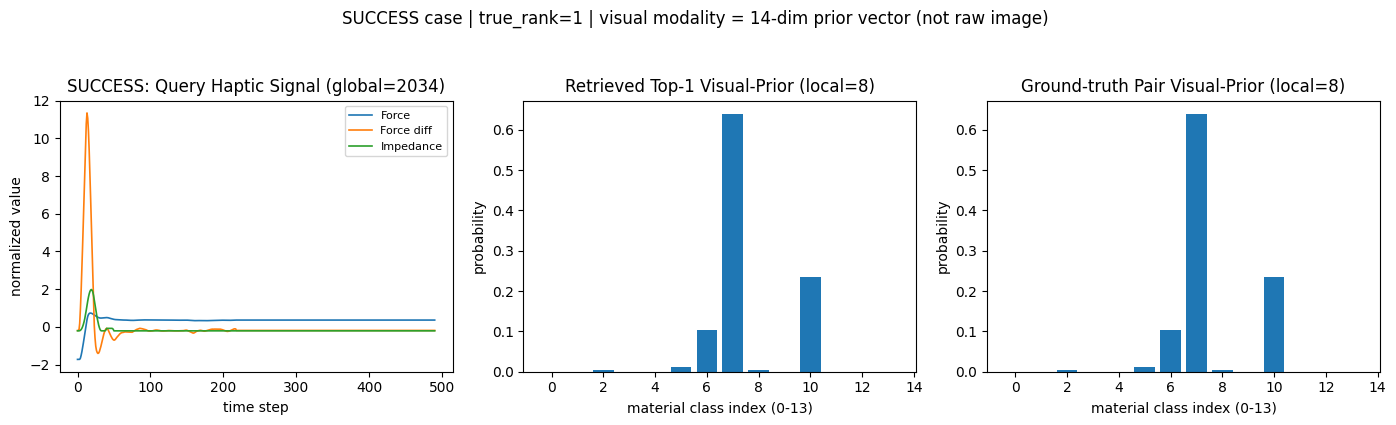

[SUCCESS] query_local=37, query_global=4857, true_rank=1, pred_local=37, pred_global=4857
  query material label: vegetable_matter
  pred prior argmax label: paper
  true pair prior argmax label: paper
  retrieved prior top-3 classes: [('paper', 0.28517720103263855), ('wood', 0.2152630239725113), ('glass', 0.20222091674804688)]
  true-pair prior top-3 classes: [('paper', 0.28517720103263855), ('wood', 0.2152630239725113), ('glass', 0.20222091674804688)]


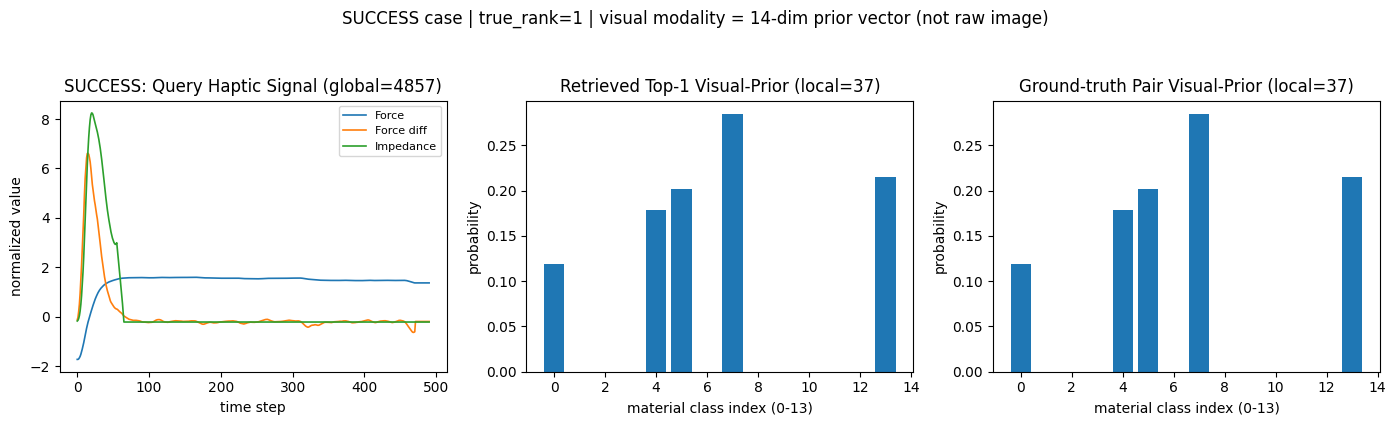

[FAILURE] query_local=0, query_global=11076, true_rank=11, pred_local=128, pred_global=1168
  query material label: cardboard
  pred prior argmax label: cardboard
  true pair prior argmax label: cardboard
  retrieved prior top-3 classes: [('cardboard', 0.7966756820678711), ('paper', 0.18922704458236694), ('aluminium', 0.003806453198194504)]
  true-pair prior top-3 classes: [('cardboard', 0.906995952129364), ('paper', 0.06570256501436234), ('wood', 0.006924998946487904)]


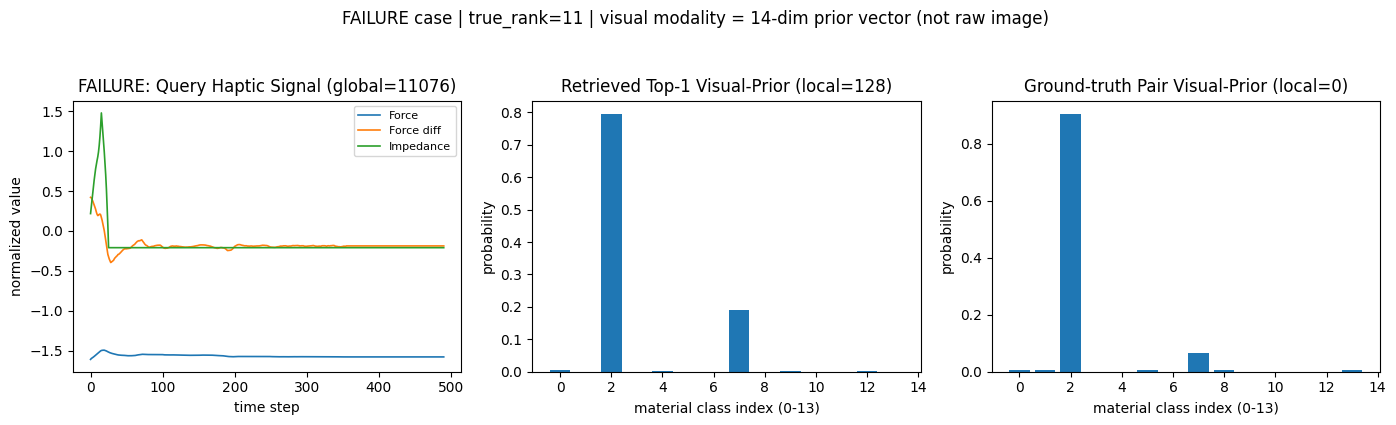

[FAILURE] query_local=2, query_global=7785, true_rank=58, pred_local=157, pred_global=10515
  query material label: hard_plastic
  pred prior argmax label: steel
  true pair prior argmax label: steel
  retrieved prior top-3 classes: [('steel', 0.4918902814388275), ('paper', 0.1987416297197342), ('aluminium', 0.08284784108400345)]
  true-pair prior top-3 classes: [('steel', 0.2717723250389099), ('paper', 0.15485119819641113), ('aluminium', 0.15485119819641113)]


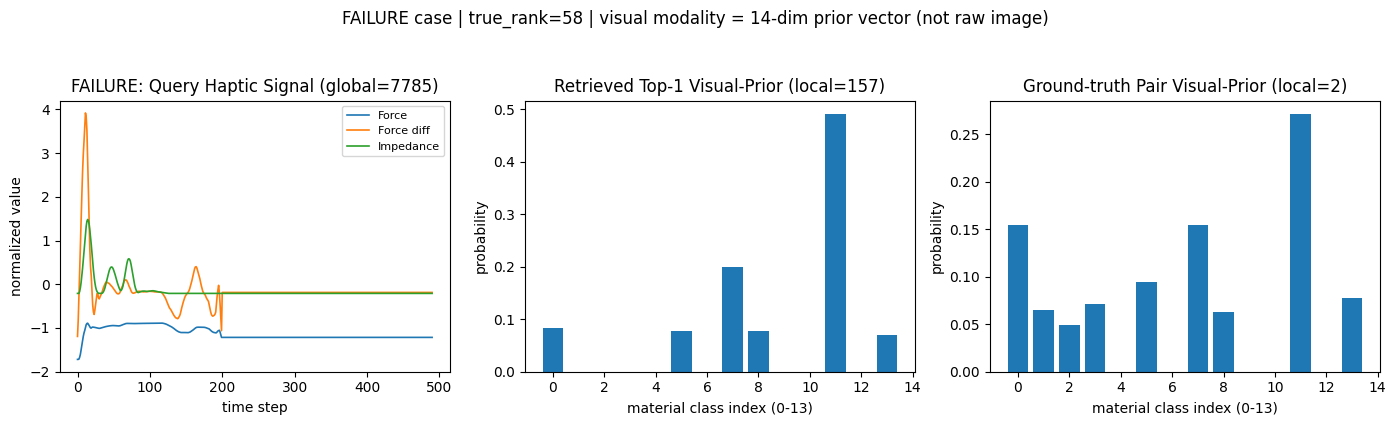

In [ ]:
# Detailed sample-level visualization (success/failure) for Problem 6 Q3
# Shows concrete data content after alignment: haptic curves + prior distributions.
# IMPORTANT: In this project, the "visual" modality is NOT raw image pixels.
# It is a 14-dim visual-prior probability vector (gpt_probs) over material classes.

print('Visualization note:')
print('- Query modality A: haptic time-series (Force / Force diff / Impedance).')
print('- Modality B ("visual"): 14-dim visual-prior probability vector from gpt_probs.')
print('- So the right two plots visualize probability distributions, not image thumbnails.')

if 'sim' not in globals() or 'ranks' not in globals() or 'sub' not in globals():
    raise ValueError('Please run the previous Problem 6 visualization cell first.')

success_ids = torch.where(ranks <= 1)[0]
failure_ids = torch.where(ranks > 10)[0]

if len(success_ids) == 0 or len(failure_ids) == 0:
    raise ValueError('Not enough success/failure samples. Try larger K or retrain model.')

# Pick 2 success + 2 failure queries for qualitative analysis
pick_success = success_ids[:2].tolist()
pick_failure = failure_ids[:2].tolist()
pick_all = [('SUCCESS', i) for i in pick_success] + [('FAILURE', i) for i in pick_failure]

# Channel names used in x_haptic from Problem 5 loader
haptic_channels = ['Force', 'Force diff', 'Impedance']

for tag, q_local in pick_all:
    # local index in current subset -> global dataset index
    q_global = int(sub[q_local].item())

    # true paired candidate is same local index q_local
    true_local = q_local

    # predicted top-1 candidate local index from similarity row
    pred_local = int(sim[q_local].argmax().item())

    # rank of the true pair
    true_rank = int(ranks[q_local].item())

    # data tensors
    haptic_signal = q[q_local].cpu().numpy()      # [3, T]
    pred_prior = c[pred_local].cpu().numpy()      # [14]
    true_prior = c[true_local].cpu().numpy()      # [14]

    pred_global = int(sub[pred_local].item())

    print(f'[{tag}] query_local={q_local}, query_global={q_global}, true_rank={true_rank}, pred_local={pred_local}, pred_global={pred_global}')
    if 'y_cls' in globals() and 'class_names' in globals():
        q_label = class_names[int(y_cls[q_global].item())]
        pred_label = class_names[int(np.argmax(pred_prior))]
        true_label_from_prior = class_names[int(np.argmax(true_prior))]
        print(f'  query material label: {q_label}')
        print(f'  pred prior argmax label: {pred_label}')
        print(f'  true pair prior argmax label: {true_label_from_prior}')

        pred_top3 = np.argsort(pred_prior)[-3:][::-1]
        true_top3 = np.argsort(true_prior)[-3:][::-1]
        print('  retrieved prior top-3 classes:', [(class_names[i], float(pred_prior[i])) for i in pred_top3])
        print('  true-pair prior top-3 classes:', [(class_names[i], float(true_prior[i])) for i in true_top3])

    fig = plt.figure(figsize=(14, 4))

    # (1) Haptic curves for the query sample
    ax1 = plt.subplot(1, 3, 1)
    for ci in range(haptic_signal.shape[0]):
        ax1.plot(haptic_signal[ci], label=haptic_channels[ci], linewidth=1.2)
    ax1.set_title(f'{tag}: Query Haptic Signal (global={q_global})')
    ax1.set_xlabel('time step')
    ax1.set_ylabel('normalized value')
    ax1.legend(fontsize=8)

    # (2) Top-1 retrieved candidate visual-prior distribution
    ax2 = plt.subplot(1, 3, 2)
    ax2.bar(np.arange(len(pred_prior)), pred_prior)
    ax2.set_title(f'Retrieved Top-1 Visual-Prior (local={pred_local})')
    ax2.set_xlabel('material class index (0-13)')
    ax2.set_ylabel('probability')

    # (3) Ground-truth paired visual-prior distribution
    ax3 = plt.subplot(1, 3, 3)
    ax3.bar(np.arange(len(true_prior)), true_prior)
    ax3.set_title(f'Ground-truth Pair Visual-Prior (local={true_local})')
    ax3.set_xlabel('material class index (0-13)')
    ax3.set_ylabel('probability')

    plt.suptitle(
        f'{tag} case | true_rank={true_rank} | visual modality = 14-dim prior vector (not raw image)',
        y=1.05
    )
    plt.tight_layout()
    plt.show()
    

### Note on what is being visualized above (important)

In this project, the second modality is **not raw image pixels**. Instead, it is a **14-dimensional visual-prior probability vector** (`gpt_probs`) over material classes.

Therefore, in the sample-level alignment plots:
- Left subplot = haptic time-series signal (query modality A)
- Middle subplot = retrieved top-1 **visual-prior distribution** (modality B)
- Right subplot = ground-truth paired **visual-prior distribution** (modality B)

So these figures visualize **cross-modal alignment between haptic signals and semantic visual priors**, not haptic-image pixel alignment.

Retrieval Recall@1: 3.50%
Retrieval Recall@5: 11.50%


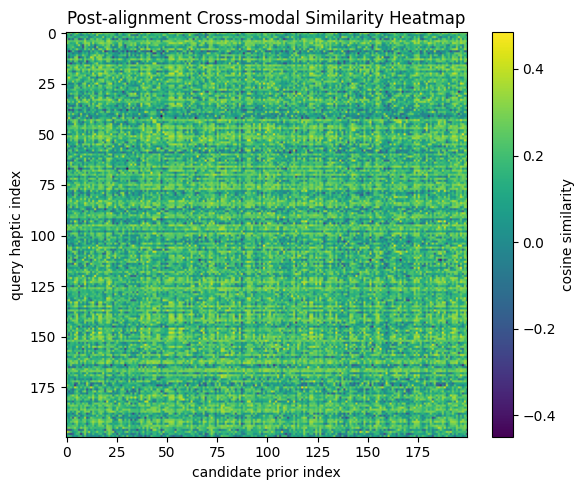

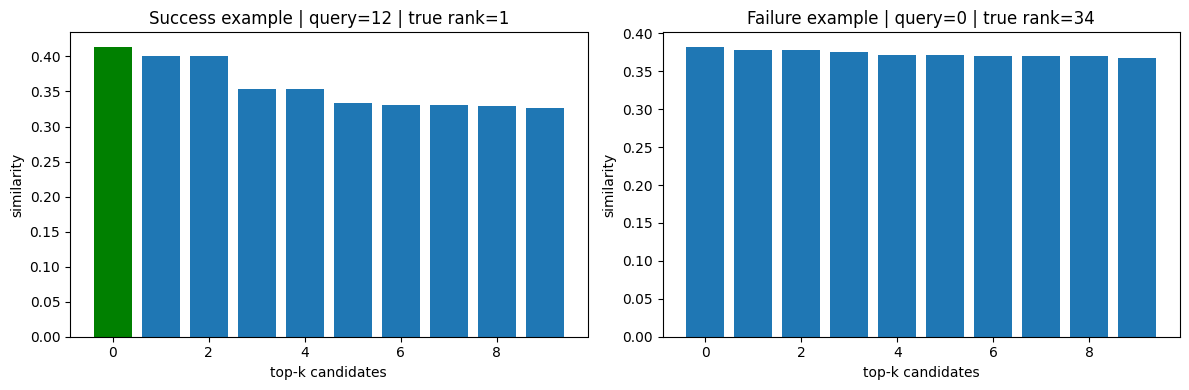

In [80]:
# Visual examples of post-alignment (for Problem 6 Q3)
import matplotlib.pyplot as plt

@torch.no_grad()
def encode_a(model, x, device):
    x = x.reshape(x.shape[0], -1).to(device)
    z = model.projector_a(model.encoder_a(x))
    return F.normalize(z, dim=-1)

@torch.no_grad()
def encode_b(model, x, device):
    x = x.reshape(x.shape[0], -1).to(device)
    z = model.projector_b(model.encoder_b(x))
    return F.normalize(z, dim=-1)

if 'cl_model' not in globals() or 'test_idx' not in globals():
    raise ValueError('Please run the contrastive training cell first.')

cl_model = cl_model.to(cl_device)
cl_model.eval()

# Use a subset for readable visualization
K = min(200, len(test_idx))
sub = test_idx[:K]
q = x_haptic[sub]
c = x_prior[sub]

q_emb = encode_a(cl_model, q, cl_device)
c_emb = encode_b(cl_model, c, cl_device)

# Similarity matrix using einsum
sim = torch.einsum('id,jd->ij', q_emb, c_emb).cpu()

# Retrieval metrics and rank statistics
order = sim.argsort(dim=1, descending=True)
true_idx = torch.arange(K).unsqueeze(1)
ranks = (order == true_idx).nonzero()[:, 1] + 1  # 1-indexed
recall1 = (ranks <= 1).float().mean().item() * 100
recall5 = (ranks <= 5).float().mean().item() * 100
print(f'Retrieval Recall@1: {recall1:.2f}%')
print(f'Retrieval Recall@5: {recall5:.2f}%')

# 1) Heatmap of pairwise similarity (diagonal means ideal alignment)
plt.figure(figsize=(6, 5))
plt.imshow(sim.numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='cosine similarity')
plt.title('Post-alignment Cross-modal Similarity Heatmap')
plt.xlabel('candidate prior index')
plt.ylabel('query haptic index')
plt.tight_layout()
plt.show()

# 2) Show one successful and one failed query
success_ids = torch.where(ranks <= 1)[0]
fail_ids = torch.where(ranks > 5)[0]

if len(success_ids) > 0 and len(fail_ids) > 0:
    s = int(success_ids[0].item())
    f = int(fail_ids[0].item())

    plt.figure(figsize=(12, 4))

    # Success example
    plt.subplot(1, 2, 1)
    top_s = torch.topk(sim[s], 10)
    xs = list(range(10))
    plt.bar(xs, top_s.values.numpy())
    true_rank_s = int((top_s.indices == s).nonzero()[0].item()) if (top_s.indices == s).any() else None
    if true_rank_s is not None:
        plt.bar(true_rank_s, top_s.values[true_rank_s].item(), color='green')
    plt.title(f'Success example | query={s} | true rank={int(ranks[s].item())}')
    plt.xlabel('top-k candidates')
    plt.ylabel('similarity')

    # Failure example
    plt.subplot(1, 2, 2)
    top_f = torch.topk(sim[f], 10)
    xf = list(range(10))
    plt.bar(xf, top_f.values.numpy())
    true_rank_f = int((top_f.indices == f).nonzero()[0].item()) if (top_f.indices == f).any() else None
    if true_rank_f is not None:
        plt.bar(true_rank_f, top_f.values[true_rank_f].item(), color='orange')
    plt.title(f'Failure example | query={f} | true rank={int(ranks[f].item())}')
    plt.xlabel('top-k candidates')
    plt.ylabel('similarity')

    plt.tight_layout()
    plt.show()
else:
    print('Not enough success/failure samples in this subset; increase K or retrain longer.')

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?